In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv')

In [3]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [6]:
X = df.iloc[:,0:3].values
y = df.iloc[:, -1]

In [7]:
print(X)

[[-5.70562824e-01  1.42034231e+00  4.95580395e-01]
 [-9.90562704e-01  5.56964528e-01  1.04506399e+00]
 [-6.74727510e-01  1.50616865e-01  1.77464503e+00]
 [ 3.88250414e-01 -3.87127181e-01 -1.10229155e-01]
 [ 1.16788229e+00 -2.41044701e-02  1.45063214e-01]
 [-8.89888979e-01 -1.58094538e+00 -4.22792727e-01]
 [-2.68510868e+00  1.84207947e-02  1.72266920e+00]
 [ 6.63187770e-01  1.85267835e-01 -1.88342383e+00]
 [ 3.19196176e-01 -2.98397020e+00 -1.51521566e+00]
 [-3.48368316e-01 -1.81101917e+00  7.46891531e-01]
 [-6.37134863e-01 -5.39574612e-01 -4.08345242e-01]
 [ 1.11594518e+00 -3.03033672e-02 -3.19590141e-01]
 [-6.89599657e-01 -3.57440729e-01 -5.41503716e-01]
 [ 2.07087853e+00  1.06979836e+00  5.93588115e-01]
 [-7.12849796e-01 -1.50891712e+00 -2.52815988e-01]
 [ 8.87925723e-01 -8.23886105e-01  4.36232115e-01]
 [-2.94033248e-01 -6.87859510e-01  7.86362918e-01]
 [-1.47394283e+00  2.01965064e+00 -2.87856456e-02]
 [-1.35804520e+00 -6.71104716e-02 -1.69436857e-01]
 [ 2.87657229e-01 -1.79480704e+

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [17]:
reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
# Residual
y_pred = reg.predict(X_test)
residual = y_test - y_pred

## 1. Linear Relationship

Every input feature should have linear or sort of linear relationship with the target feature.

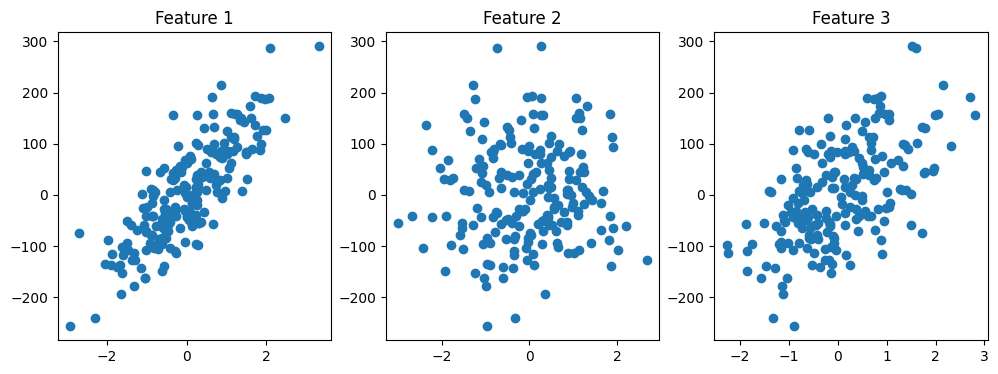

In [10]:
fig, (one, two, three) = plt.subplots(ncols=3, figsize=(12, 4))
one.scatter(df['feature1'], df['target'])
one.set_title('Feature 1')

two.scatter(df['feature2'], df['target'])
two.set_title('Feature 2')

three.scatter(df['feature3'], df['target'])
three.set_title('Feature 3')

plt.show()

## 2. Multicollinearity

When input features are highly correlated with each other (meaning if one feature increases or decreases then other feature also increases or decreases) then multicollinearity problem arises.

vif = 1 (no multicollinearity)

1 < vif < 5 (less multicollinearity)

5 <= vif <= 10 (moderate multicollinearity)

vif > 10 (high multicollinearity)

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = []
for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [14]:
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.001471,1.014364,1.012964


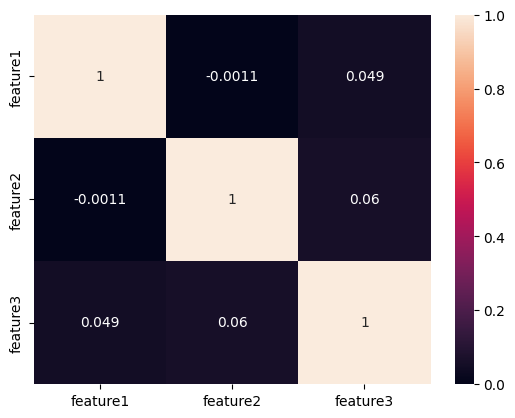

In [16]:
# Another Technique
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)
plt.show()

Above shown matrix is correlation matrix. corrletion value = 1 means perfectly correlated. And we see that features are not correlated with one another.

## 3. Normality of Residual

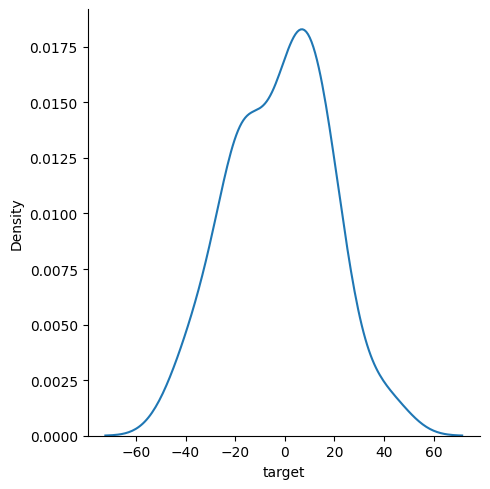

In [19]:
sns.displot(residual,kind='kde')
plt.show()

When we plot the graph of residual, it must be normally distributed. i.e. **bell shaped**

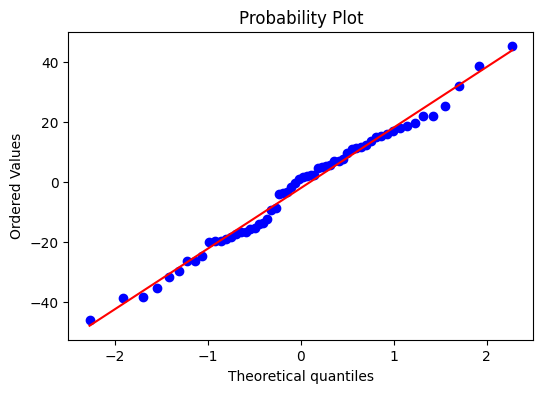

In [20]:
# QQ Plot

import scipy as sp

fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

## 4. Homoscedasticity

The spread of residual should be uniformly distirbuted rather than dense in some specific area.

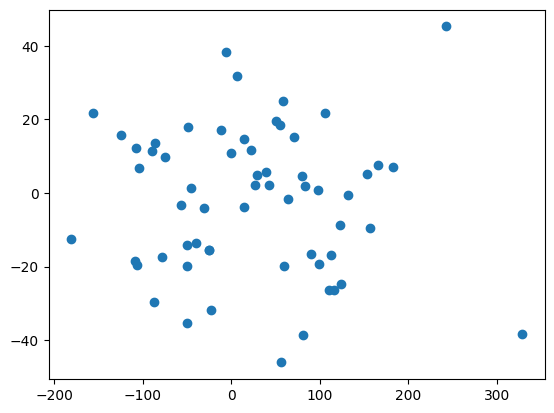

In [21]:
plt.scatter(y_pred,residual)
plt.show()

## 5. Autocorrelation of Residuals

No relationship between the residual. Negative correlation.

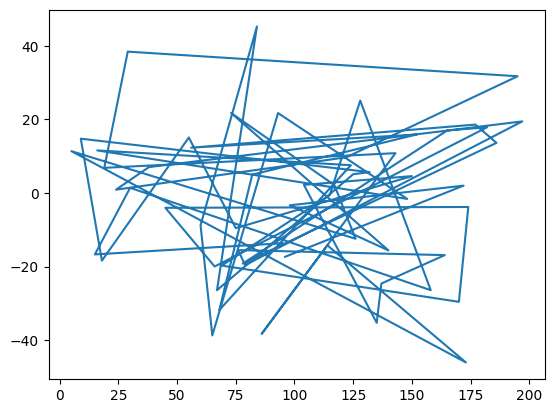

In [22]:
plt.plot(residual)
plt.show()